# Exe5 - Decision trees

## Problem 1 - Classification tree from scratch

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

def load(name):  # col 0 = label, remaining columns = features
    d = np.loadtxt(name, delimiter=",", skiprows=1)
    return d[:, 1:], d[:, 0].astype(int)

### (1a) Entropy

In [2]:
# 1a 
def entropy(y):
    p = np.unique(y, return_counts=True)[1] / len(y)    # unique returns the unique values and their counts, we only need the counts
    return -np.sum(p * np.log2(p)) + 0.0  # + 0.0 turns -0.0 into 0.0

print("pure set      :", entropy([1, 1, 1, 1]))
print("p0 = 0.5      :", entropy([0, 0, 1, 1]))
print("p0 = 0.9      :", round(entropy([0] * 9 + [1]), 3))
print("4 classes     :", entropy([0, 1, 2, 3]))

pure set      : 0.0
p0 = 0.5      : 1.0
p0 = 0.9      : 0.469
4 classes     : 2.0


### (1b) Best split of one feature

In [ ]:
# 1b
# best threshold on a single feature; impurity is a parameter so that Problem 2 reuses the same code
def best_split(x, y, impurity=entropy):
    N = len(y)
    best = (None, np.inf)  # (threshold, score)

    for t in np.unique(x)[:-1]:  # the largest value would leave subset 2 empty
        left = x <= t

        impurity_left = impurity(y[left])
        impurity_right = impurity(y[~left])
        num_elem_left = left.sum()
        num_elem_right = (~left).sum()

        score = num_elem_left / N * impurity_left + num_elem_right / N * impurity_right
        
        if score < best[1]:
            best = (t, score)
            
    return best

### (1c) Best split across all features

In [4]:
# 1c 
# best (feature, threshold, score) over all features
def find_best_split(X, y, impurity=entropy):
    best = (None, None, np.inf)  # (feature, threshold, score)

    # iterate over all features (columns) of X and find the best split for each feature, then keep track of the best overall split
    # it will the one over wich the node is going to cut data
    for j in range(X.shape[1]):
        t, score = best_split(X[:, j], y, impurity)
        if score < best[2]:
            best = (j, t, score)
            
    return best

### (1d) Classification tree (recursion)

In [ ]:
# 1d 
# every node is an object; leaf nodes have no children
class Node:
    def __init__(self, y, impurity, leaf):  # method called when creating a new Node object
        self.n = len(y)  # number of samples in the node
        self.imp = impurity(y)  # impurity of the node
        self.value = leaf(y)  # prediction of the node
        self.feature = self.threshold = self.left = self.right = None

majority = lambda y: np.bincount(y).argmax()  # majority class of a set
threshold = 1e-9  # impurity treshold

def generate_tree(X, y, max_depth, impurity=entropy, leaf=majority):
    node = Node(y, impurity, leaf)

    if node.imp < threshold or max_depth == 0:  # stop splitting if the node is pure or if we reached the maximum depth
        return node

    j, t, _ = find_best_split(X, y, impurity)

    if j is None:  # identical samples, no split possible
        return node

    node.feature = j
    node.threshold = t
    left = X[:, j] <= t

    node.left = generate_tree(X[left], y[left], max_depth - 1, impurity, leaf)
    node.right = generate_tree(X[~left], y[~left], max_depth - 1, impurity, leaf)
    
    return node

def predict(node, X):  # send each sample down the tree
    
    if node.left is None:
        return np.full(len(X), node.value, float)

    out = np.empty(len(X))
    
    m = X[:, node.feature] <= node.threshold

    out[m]= predict(node.left, X[m])
    out[~m] = predict(node.right, X[~m])
    
    return out

### (1e) Test on `blobs.csv` and `flame.csv`

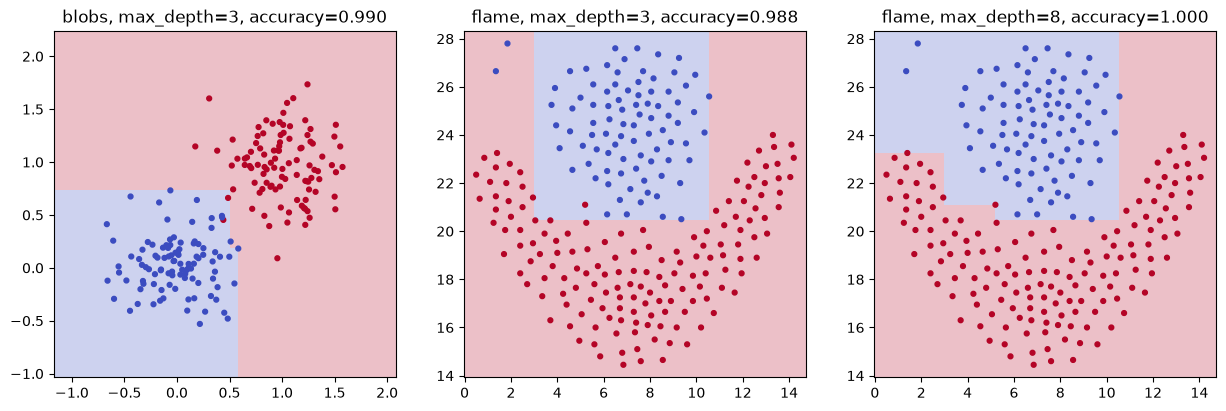

In [6]:
# 1e 
# data + regions found by the tree
def plot_regions(X, y, tree, ax, title):
    x_values = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
    y_values = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)

    grid_x, grid_y = np.meshgrid(x_values, y_values)  # 300 x 300 grid of points covering the data
    
    grid_points = np.column_stack([grid_x.flatten(), grid_y.flatten()])  # one row per grid point
    grid_class = predict(tree, grid_points).reshape(grid_x.shape)  # class predicted at every grid point

    ax.pcolormesh(grid_x, grid_y, grid_class, cmap="coolwarm", vmin=0, vmax=1, alpha=0.25, shading="auto")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=12)
    ax.set_title(title)

Xb, yb = load("blobs.csv")
Xf, yf = load("flame.csv")
acc = lambda tree, X, y: np.mean(predict(tree, X) == y)

DEPTH_BLOBS = 3
DEPTH_FLAME = (3, 8)

config1 = (Xb, yb, DEPTH_BLOBS, "blobs")
config2 = (Xf, yf, DEPTH_FLAME[0], "flame")
config3 = (Xf, yf, DEPTH_FLAME[1], "flame")

trees = [config1, config2, config3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (X, y, d, name) in zip(axes, trees):
    tree = generate_tree(X, y, d)
    plot_regions(X, y, tree, ax, f"{name}, max_depth={d}, accuracy={acc(tree, X, y):.3f}")
plt.show()

### (1f) Diagram of the learned rules

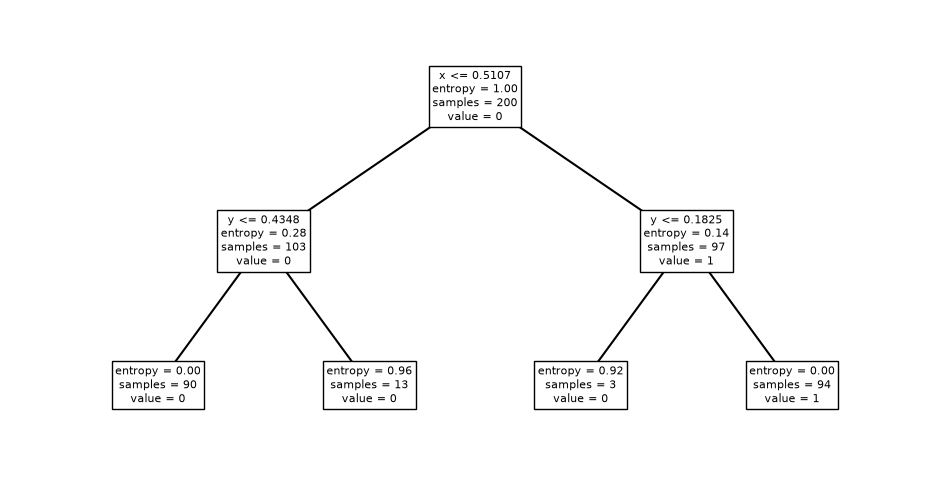

In [7]:
# 1f 
# draw the tree: leaves get consecutive x positions, a decision node sits above its two children
def plot_tree(root, names, imp="entropy", figsize=(12, 6)):
    i = 0  # next free x position for a leaf
    fig, ax = plt.subplots(figsize=figsize)

    def draw(n, d):
        # draw the subtree rooted at node n, at depth d
        nonlocal i
        if n.left is None:
            x = i
            i += 1
        else:
            # recursion to draw the left and right subtrees, and get their x positions
            xl = draw(n.left, d + 1)
            xr = draw(n.right, d + 1)
            x = (xl + xr) / 2

            # draw lines from the decision node to its children left and right
            for xc in (xl, xr):
                ax.plot([x, xc], [-d, -d - 1], "k", zorder=1)

        # prepare the text for the feature and threshold used
        cond = "" if n.left is None else f"{names[n.feature]} <= {n.threshold:.4g}\n"

        # print text and rectangle for the node: condition, impurity, number of samples, and predicted value. printed in position (x, -d)
        ax.text(x, -d, f"{cond}{imp} = {n.imp:.2f}\nsamples = {n.n}\nvalue = {n.value:.4g}",
                    ha="center", va="center", fontsize=8, 
                    zorder=2, bbox=dict(boxstyle="square", 
                    fc="white"))

        return x

    # draw the tree starting from the root at depth 0
    draw(root, 0)
    ax.set_xlim(-0.7, i - 0.3)
    ax.set_ylim(-DEPTH_PLOT - 0.6, 0.6)
    ax.axis("off")
    plt.show()

DEPTH_PLOT = 2
plot_tree(generate_tree(Xb, yb, DEPTH_PLOT), ["x", "y"])

### (1g) Tic-tac-toe: generalization

In [ ]:
# 1g - train/test accuracy of the tic-tac-toe tree for several depths, with and without duplicated boards
Xt, yt = load("tictac.csv")

# problem with duplicates -> data leakage
_, keep = np.unique(Xt, axis=0, return_index=True)  # one row per distinct board
sets = {"with duplicates": (Xt, yt), "without duplicates": (Xt[keep], yt[keep])}

for name, (X, y) in sets.items():
    
    # random permutation of the indexes of the samples to split data
    i = np.random.default_rng(0).permutation(len(y))
    tr, te = np.split(i, [int(0.8 * len(y))])  # 80 / 20 split
    
    print(f"{name}: {len(y)} boards")

    for d in (1, 2, 4, 6, 8, 12, 20):  # depths to try
        tree = generate_tree(X[tr], y[tr], d)
        print(f"  max_depth={d:2d}   train acc {acc(tree, X[tr], y[tr]):.3f}   test acc {acc(tree, X[te], y[te]):.3f}")

with duplicates: 6551 boards
  max_depth= 1   train acc 0.308   test acc 0.298
  max_depth= 2   train acc 0.385   test acc 0.363
  max_depth= 4   train acc 0.490   test acc 0.481
  max_depth= 6   train acc 0.597   test acc 0.586
  max_depth= 8   train acc 0.690   test acc 0.651
  max_depth=12   train acc 0.937   test acc 0.838
  max_depth=20   train acc 1.000   test acc 0.903
without duplicates: 3903 boards
  max_depth= 1   train acc 0.299   test acc 0.327
  max_depth= 2   train acc 0.382   test acc 0.416
  max_depth= 4   train acc 0.509   test acc 0.512
  max_depth= 6   train acc 0.604   test acc 0.580
  max_depth= 8   train acc 0.716   test acc 0.645
  max_depth=12   train acc 0.943   test acc 0.706
  max_depth=20   train acc 1.000   test acc 0.700


### (1h) Bonus - play tic-tac-toe against the tree

In [9]:
# 1h
# the human chooses x (1) or o (-1). x starts; the computer asks the tree for its move

X, y = sets["without duplicates"]
game_tree = generate_tree(X, y, 12)
LINES = [(0, 1, 2), (3, 4, 5), (6, 7, 8), (0, 3, 6), (1, 4, 7), (2, 5, 8), (0, 4, 8), (2, 4, 6)]

# check all winning lines for a winner, return 0 if no winner
# return b[a] only if the line is winning 
def winner(b):
    for a, c, d in LINES:
        if b[a] != 0 and b[a] == b[c] == b[d]:
            return b[a]
    return 0

# printing function  fro the board
show = lambda b: print("\n".join(" ".join(".xo"[v] for v in b[r:r + 3]) for r in (0, 3, 6)), "\n")

def play(tree, human=1):
    b = np.zeros(9, int)
    turn = 1

    while winner(b) == 0 and (b == 0).any():
       
        if turn == human:   # human turn
            m = -1
            while m not in np.flatnonzero(b == 0):  # return the indices of the free cells
                m = int(input("your move (0-8): "))
                
        else:  # computer turn       
            m = int(predict(tree, b[None])[0])
            if b[m] != 0:  # the tree can be wrong and take a non free cell, fall back to the first free square
                m = np.flatnonzero(b == 0)[0]

        b[m] = turn
        turn = -turn
        show(b)

    print({1: "x wins", -1: "o wins", 0: "draw"}[winner(b)])

## Problem 2 - Regression tree

### (2a) Regression tree

In [10]:
# 2a 
# same functions, different impurity and leaf

mse = lambda y: np.mean((y - y.mean()) ** 2)

def regression_tree(X, y, max_depth):
    return generate_tree(X, y, max_depth, impurity=mse, leaf=np.mean)

### (2b) `global-temperatures.csv`

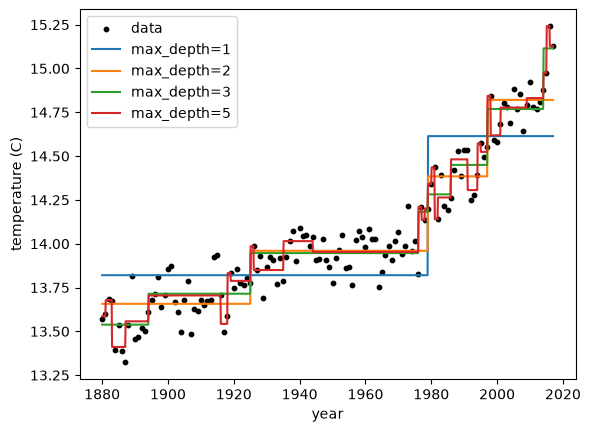

In [11]:
# 2b 
# predicted line for several depths
G = np.loadtxt("global-temperatures.csv", comments="#")
years = G[:, :1]
temp = G[:, 1]
grid = np.linspace(years.min(), years.max(), 1000)[:, None]

plt.scatter(years, temp, s=10, c="k", label="data")

for d in (1, 2, 3, 5):  # depths to try
    prediction = predict(regression_tree(years, temp, d), grid)
    
    plt.plot(grid, prediction, label=f"max_depth={d}")
plt.xlabel("year"); plt.ylabel("temperature (C)"); plt.legend(); plt.show()

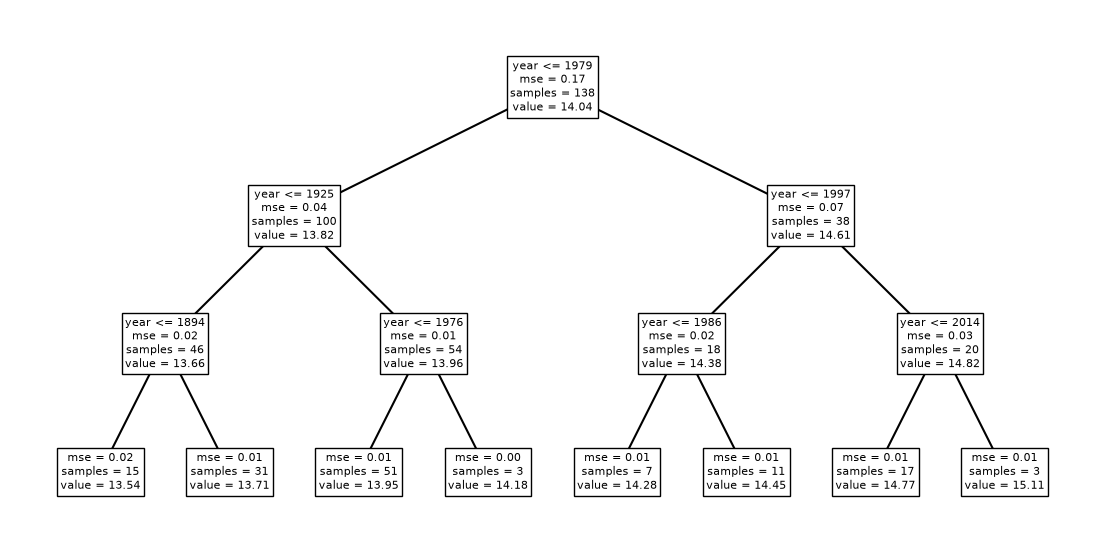

In [12]:
# 2b 
# diagram of the tree with max_depth = 3
DEPTH_PLOT = 3
plot_tree(regression_tree(years, temp, 3), ["year"], imp="mse", figsize=(14, 7))

### (2c) `auto-mpg.csv`: $R^2$ as a function of the depth

max_depth= 1   R2=0.5803
max_depth= 2   R2=0.7334
max_depth= 3   R2=0.8290
max_depth= 4   R2=0.8891
max_depth= 5   R2=0.9202
max_depth= 6   R2=0.9439
max_depth= 7   R2=0.9676
max_depth= 8   R2=0.9794
max_depth= 9   R2=0.9864
max_depth=10   R2=0.9927
max_depth=11   R2=0.9962
max_depth=12   R2=0.9990
max_depth=13   R2=0.9997
max_depth=14   R2=0.9999
max_depth=15   R2=1.0000


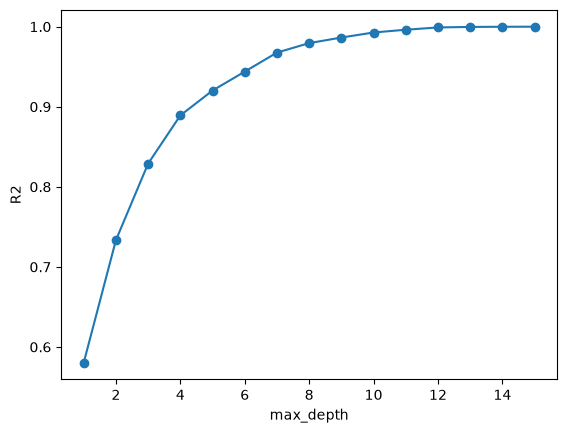

In [ ]:
# 2c 
# R^2 of the regression tree for increasing depth (response = first column)

# load data
A = np.loadtxt("auto-mpg.csv", comments="#")
y, X = A[:, 0], A[:, 1:]

# function to compute R^2 -> (1 - E) / E_mean
r2 = lambda y, p: 1 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2)

depths = range(1, 16)

R2 = [r2(y, predict(regression_tree(X, y, d), X)) for d in depths]  # list comprehension to compute R^2 for each depth
for d, v in zip(depths, R2):
    print(f"max_depth={d:2d}   R2={v:.4f}")

plt.plot(depths, R2, "o-"); plt.xlabel("max_depth"); plt.ylabel("R2"); plt.show()

The plot is monotonically increasing. Each split replaces a subset by two subsets whose values are their own means; the mean is the constant that minimizes the squared error in a set, so a split can never increase the error, and $R^2$ never decreases with depth. With a large depth each leaf holds very few samples and the tree reproduces the training data. This is overfitting (the same mechanism as the step function in 2b): the training $R^2$ grows, but it says nothing about performance on new data.

In [16]:
# play a game
# instruction: human=1 you are x (you start), human=-1 you are o
play(game_tree, human=1)


. . .
. x .
. . . 

o . .
. x .
. . . 

o . .
. x x
. . . 

o . .
o x x
. . . 

o x .
o x x
. . . 

o x .
o x x
o . . 

o wins
